# Five-player Cournot game: fixed tangent coordinates and accumulated map

This deterministic example uses the same setup as the companion Cournot DTB
notebook, but selects one set of neural-network parameter coordinates before
time stepping and keeps it fixed. The parameters evolve, and the particle-map
values are accumulated independently. There are no resets or NN refits.

With $b=2$, $\mu=7/4$, and $s_i=\sum_{j\ne i}x_j$, the game velocity is

$$F_i(x)=2b\left(\max\{\mu s_i(1-s_i),0\}-x_i\right).$$

Initial particles are uniform on $[0,1]^5$. Run all cells for the point clouds in $(x_1,x_2)$, $(x_2,x_3)$, $(x_3,x_4)$, and $(x_4,x_5)$, followed by the projection-error trajectory.

[Open in Colab](https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex%2Fgame-dynamics-dtb/DTB_Game_Ver2/cournot_5d_b2_mu7_4_solution_map_dtb.ipynb)


In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

# Use the existing helpers locally, or obtain them when running in Colab.
module_files = ('dtb.py', 'run_game_dtb.py')
module_dir = next((p for p in (Path.cwd(), Path.cwd() / 'DTB_Game_Ver2')
                   if all((p / name).is_file() for name in module_files)), None)
if module_dir is None:
    if not Path('/content').is_dir():
        raise FileNotFoundError('Run from the repository root or DTB_Game_Ver2.')
    repo = Path('/content/dtb-colab-experiments')
    if not repo.exists():
        subprocess.run([
            'git', 'clone', '--depth', '1', '--branch', 'codex/game-dynamics-dtb',
            'https://github.com/sun-mengwei/dtb-colab-experiments.git', str(repo),
        ], check=True)
    module_dir = repo / 'DTB_Game_Ver2'
sys.path.insert(0, str(module_dir.resolve()))

from dtb import flat_params
from run_game_dtb import ResidualMLPMap, game_dtb_basis_matrices

output_dir = Path("/content/cournot_5d_results")
output_dir.mkdir(parents=True, exist_ok=True)

## Parameters

The residual tanh MLP and particle map both start at the identity. Select one
set of 128 parameter coordinates before time stepping and keep those
coordinates fixed. At each step, recompute their tangent vectors at the
current parameters, project the game velocity, and use the same coefficients
to update the parameters and the accumulated particle map.


In [2]:
SEED = 0
DIM = 5
COURNOT_B = 2.0
COURNOT_MU = 7 / 4
N_PARTICLES = 3000

H = 0.005
T_FINAL = 2
SNAPSHOT_TIMES = (0.0, 0.5, 1.0, T_FINAL)
WIDTH, DEPTH = 16, 2
BASIS_SIZE = 128
SVD_RTOL = 1e-6  # Retain singular values above SVD_RTOL * s_max.
JACOBIAN_CHUNK = 256

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float64
torch.set_num_threads(min(4, torch.get_num_threads()))


def game_velocity(x):
    rivals = x.sum(dim=-1, keepdim=True) - x
    best_response = (COURNOT_MU * rivals * (1 - rivals)).clamp_min(0.0)
    return 2 * COURNOT_B * (best_response - x)

## Fixed parameter coordinates with evolving tangent vectors

Keep the reference labels $z_i$ fixed and initialize $X_i^0=z_i$. Select one
parameter-coordinate set $S$ before the loop. At step $k$, evaluate

$$J_i^k=\partial_{\theta_S}T_{\theta_k}(z_i),
\qquad g_i^k=F(X_i^k).$$

The coordinate indices $S$ remain fixed, while the tangent vectors $J_i^k$
are recomputed because $\theta_k$ changes.

For $A=J^k/\sqrt N=U\Sigma V^\top$ and
$y=\operatorname{vec}(g^k)/\sqrt N$, retain
$s_\ell>\texttt{SVD\_RTOL}\,s_{\max}$ and solve

$$\alpha^k=V_{\rm keep}\Sigma_{\rm keep}^{-1}U_{\rm keep}^\top y.$$

Update the selected parameters and the particle values using the same
old-step Jacobian and coefficient vector:

$$
(\theta_{k+1})_S=(\theta_k)_S+h_k\alpha^k,
\qquad
X_i^{k+1}=X_i^k+h_kJ_i^k\alpha^k.
$$

Unselected parameter entries remain unchanged. The parameter increment is
$h_k\alpha^k$ on $S$; $J^k\alpha^k$ has particle-space dimensions and updates
$X$. The new particle values are never replaced by
$T_{\theta_{k+1}}(z_i)$. No reset or refit is performed.

The error curve records $\|J^k\alpha^k-g^k\|/\sqrt N$ at the start of each
step. Every snapshot comes from the accumulated values

$$X_K(z_i)=z_i+\sum_{k=0}^{K-1}h_kJ_i^k\alpha^k.$$

`X_final` stores the final accumulated values with shape
`(N_PARTICLES, DIM)`.


In [3]:
# Rerunning this cell restarts theta and the independently accumulated X.
torch.manual_seed(SEED)
basis_generator = torch.Generator().manual_seed(SEED + 1)
z = torch.rand(N_PARTICLES, DIM, generator=torch.Generator().manual_seed(SEED),
               dtype=DTYPE).to(DEVICE)
x = z.clone()  # Independently accumulated particle map X^k(z_i).
model = ResidualMLPMap(dim=DIM, width=WIDTH, depth=DEPTH,
                       activation='tanh', dtype=DTYPE).to(DEVICE)
theta, structure, _ = flat_params(model)

# Select one parameter-coordinate set S and reuse it for every step.
indices = torch.randperm(theta.numel(), generator=basis_generator)
selected = indices[:BASIS_SIZE].sort().values.to(DEVICE)

snapshot_times = np.unique(np.round(SNAPSHOT_TIMES, 12))
times = np.unique(np.round(np.r_[np.arange(0, T_FINAL, H), snapshot_times, T_FINAL], 12))
projection_times = times[:-1]
projection_error = []
clouds = {0.0: x.cpu().numpy().copy()}

for k, t in enumerate(projection_times):
    _, _, J_flat = game_dtb_basis_matrices(
        theta, selected, z, model, structure, chunk=JACOBIAN_CHUNK)
    J_flat = J_flat.detach()

    velocity = game_velocity(x)
    A = J_flat / np.sqrt(N_PARTICLES)
    target = velocity.reshape(-1) / np.sqrt(N_PARTICLES)
    U, s, Vh = torch.linalg.svd(A, full_matrices=False)
    keep = s > SVD_RTOL * s[0]
    alpha = Vh[keep].T @ ((U[:, keep].T @ target) / s[keep])
    tangent_velocity = (J_flat @ alpha).reshape_as(x)
    error = (tangent_velocity - velocity).square().sum(dim=1).mean().sqrt()
    if not torch.isfinite(error):
        raise FloatingPointError(f'Nonfinite tangent projection at t={t:g}.')
    projection_error.append(error.item())

    next_time = float(times[k + 1])
    h = next_time - float(t)
    # Both increments use the same old-step J(theta_k, z) and alpha_k.
    theta[selected] += h * alpha
    x = (x + h * tangent_velocity).detach()
    if not torch.isfinite(theta).all() or not torch.isfinite(x).all():
        raise FloatingPointError(f'Nonfinite state at t={next_time:g}.')

    if next_time in snapshot_times:
        clouds[next_time] = x.cpu().numpy().copy()

# Final accumulated map values on the fixed labels z.
X_final = x.detach().clone()
projection_error = np.asarray(projection_error)

## Point-cloud projections

Rows show the four adjacent coordinate pairs; columns show physical time. All particles are displayed, with common axis limits across the figure.

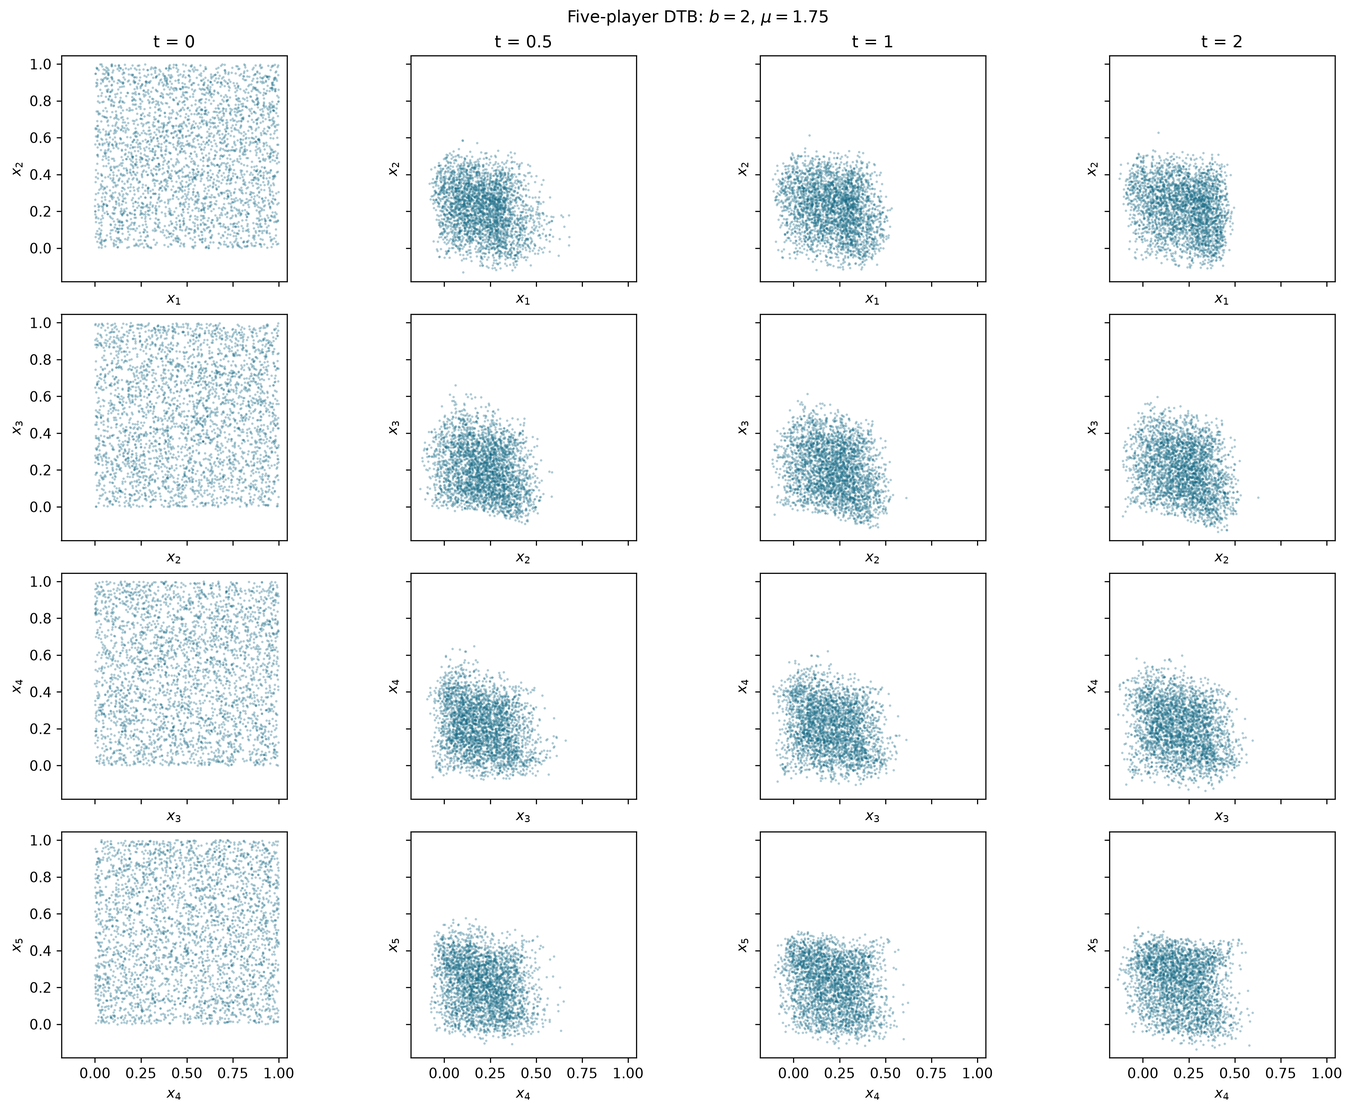

In [4]:
pairs = ((0, 1), (1, 2), (2, 3), (3, 4))
fig, axes = plt.subplots(4, len(clouds), figsize=(3.5 * len(clouds), 11),
                         sharex=True, sharey=True, squeeze=False, layout='constrained')
lo = min(points.min() for points in clouds.values())
hi = max(points.max() for points in clouds.values())
padding = 0.04 * max(hi - lo, 1e-6)

for row, (i, j) in enumerate(pairs):
    for col, (t, points) in enumerate(clouds.items()):
        ax = axes[row, col]
        ax.scatter(points[:, i], points[:, j], s=3, alpha=0.35,
                   color='#176b87', linewidths=0, rasterized=True)
        ax.set(xlabel=fr'$x_{i + 1}$', ylabel=fr'$x_{j + 1}$',
               xlim=(lo - padding, hi + padding), ylim=(lo - padding, hi + padding))
        ax.set_aspect('equal', adjustable='box')
        if row == 0:
            ax.set_title(f't = {t:g}')
fig.suptitle(fr'Five-player DTB: $b={COURNOT_B:g}$, $\mu={COURNOT_MU:g}$')
fig.savefig(output_dir / "point_clouds.png",
            dpi=300, bbox_inches="tight")
plt.show()

## Projection-error trajectory

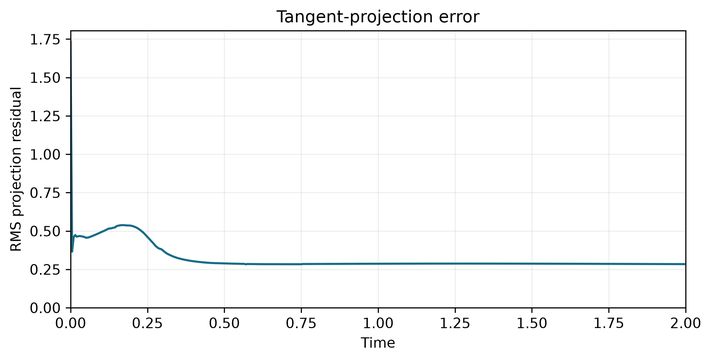

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5), layout='constrained')
ax.plot(projection_times, projection_error, color='#176b87', linewidth=1.5)
ax.set(xlabel='Time', ylabel='RMS projection residual',
       title='Tangent-projection error', xlim=(0, T_FINAL), ylim=(0, None))
ax.grid(alpha=0.2)
fig.savefig(output_dir / "projection_error.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from pathlib import Path
import shutil
from google.colab import files

run_folder = Path(output_dir)

zip_path = shutil.make_archive(
    f"/content/{run_folder.name}",
    "zip",
    root_dir=str(run_folder.parent),
    base_dir=run_folder.name,
)

files.download(zip_path)